# The Solow Growth Model

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy import optimize
import sympy as sm
from types import SimpleNamespace
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# plotting
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

In [2]:
import SolowModel as SolowModel
from SolowModel import Solow_model

from SolowModel import SolowModelwithHumanCapital

model = Solow_model()

## Model description

Consider the **standard Solow-model** where:

1. $K_t$ is capital
2. $L_t$ is labor (growing with a constant rate of $n$)
3. $A$ is technology (constant over time)
4. $Y_t = F(K_t,A_tL_t)$ is GDP

We set population growth and technology growth equal to zero to keep things simple.

For every period t, output is given by:
$$
Y_{t} = F(K_{t},L_{t})
$$

The **production function** has **constant returns to scale** such that

$$
F(\lambda K, \lambda L) = \lambda F(K,L)
$$

The production function is a **Cobb-Douglas** production function
$$
F(K_{t},L_{t})=A K_{t}^{\alpha}L_{t}^{1-\alpha}, 0<=\alpha <=1
$$


We assume **closed economy** which implies 
$$
I_{t} = S_{t} 
$$

**Saving** is a constant fraction of GDP

$$ 
S_t = sY_t,\,s\in(0,1)
$$

The capital depreciates with the rate $\delta$ in each period. Such that **capital accumulates** according to

$$
K_{t+1}=S_{t}+(1-\delta)K_{t}=sF(K_{t},L_{t})+(1-\delta)K_{t}, \delta \in (0,1)
$$

As we don't have population growth, $L_t$ is some constant L.

Capital per capita is given by $k_{t}=K_{t}/L$. We can write the capital accumulation equation as

$$
k_{t+1}= s \frac{F(K_{t}L)}{L} + (1-\delta)k_{t} = sAk_{t}^\alpha + (1-\delta)k_{t}
$$


## Analytical solution

At first, we will solve the model analytically using sympy.

In [3]:
SolowModel.Solow_analytical()

The steady state equation for k is:


(A*s/delta)**(-1/(alpha - 1))

## Numerical solution

We will now use the analytical steady state of k to find a numerical solution given some parameter definitions.

In [4]:
model.run()

The steady state for k is 7.24578931411126


Now, we will make a visualisation of the transition of capital to the steady state.

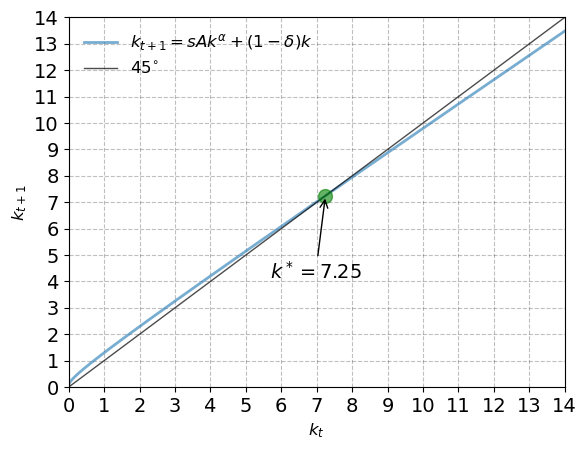

In [5]:
model = Solow_model()
model.plot45()

## Analysis - Simulation and comparative statics
We want to look further into the dynamics of our model by comparing it with the theoretical dynamics


### Different inital levels of capital

We will now show the capital paths for three distinct initial capital levels.

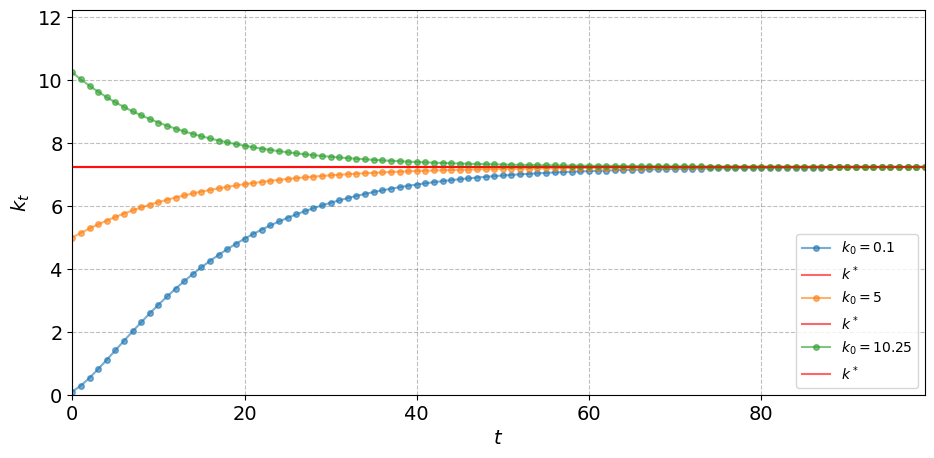

In [6]:
k_ini_values = np.array([0.1, 5, 10.25])
model.simulate(k_ini_values)

We see that for all initial levels of capital, the capital accumulation will converge towards the steady state level k*.

### Different Savings rates
We now look at how different savings rates affect the steady state of capital. We test that our model follows the theoretically positive relationship.

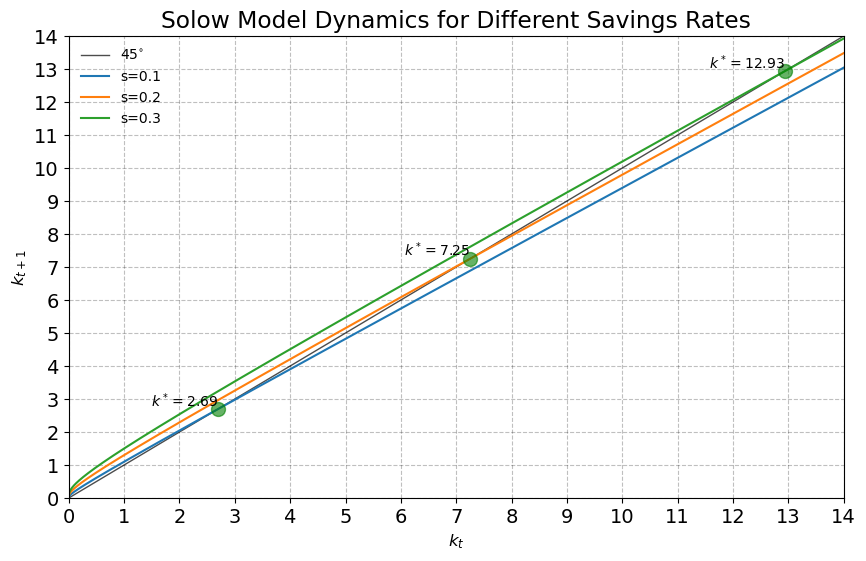

In [7]:
newmodel_combined = Solow_model()
newmodel_combined.plot_combined([0.1, 0.2, 0.3])

We can see that our model corroporates the theoretical relationship.

### A shock to technology
We now simulate an upwards shock to technology in our model to check if it matches a theoretical shock, where steady state of capital with permanently increase.  

The steady state for k is 7.24578931411126
The steady state for k is 9.966176578193432


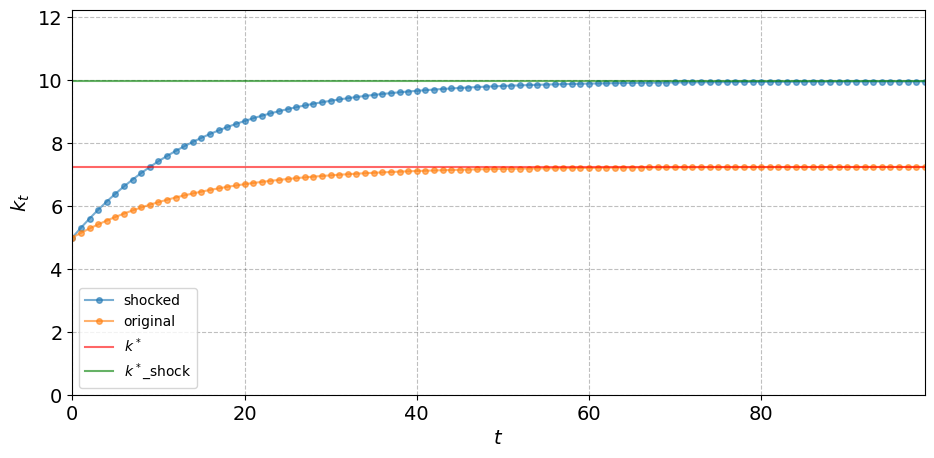

In [8]:
# Create an instance of Solow_model
newmodel = Solow_model()

# Set the shock to A
newmodel.A = 2.5
for i in range(0, 100):
    newmodel.newA[i] = 2.5

# Plot the combined graph before and after the technology shock
newmodel.plot_technology_shock_combined()

We find that our model coorporates with the theoretical model. 

# Extension of the model
## Solow model with human capital

We now create an extension of the classic Solow model that includes human capital in the production function. 

The model equations:

$$
Y_t = K_t ^\alpha H_t ^\phi (A_t*L_t)^{(1-\alpha-\phi)}
$$

The technology adjusted variables:
$$
\tilde{y} _t = \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi
$$

The technology adjusted capital accumulation equations:

$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K \tilde{y}_t +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{y}_t +(1-\delta)\tilde{h}_t)
$$

Inserting the equation for $\tilde{y}_t$ yields:
$$
\tilde{k}_{t+1}=\frac{1}{(1+n)(1+g)} (s_K\tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{k}_t)
$$

$$
\tilde {h}_{t+1}=\frac{1}{(1+n)(1+g)} (s_H \tilde{k} _t ^\alpha  \tilde{h}_t ^\phi +(1-\delta)\tilde{h}_t)
$$

## Analytical solution

In [9]:
SolowModel.SolowHuman_analytical_capital()

The steady state equation for k is:


((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1))

In [10]:
SolowModel.SolowHuman_analytical_humancapital()

The steady state equation for h is:


((delta + g*n + g + n)/(k**alpha*sh))**(1/(phi - 1))

Now, we want to combine the SS values. I.e. use the SS value of human capital in the SS equation for physical capital. We do this by substituting the SS value of human capital into the SS capital equation and isolate k. After that, we can insert the expression for $k^*$ in the steady state equation for h. Thereby, we will have a SS value for both human capital and physical capital.

In [11]:
SolowModel.SolowHuman_analytical_combined()

The combined steady state equation for k is:


Eq(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)), (sk*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha*(((delta + g*n + g + n)/(sh*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha))**(1/(phi - 1)))**phi + ((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1))*(1 - delta))/((g + 1)*(n + 1)))

The combined steady state equation for h is:


Eq(((delta + g*n + g + n)/(sh*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha))**(1/(phi - 1)), (sh*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha*(((delta + g*n + g + n)/(sh*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha))**(1/(phi - 1)))**phi + ((delta + g*n + g + n)/(sh*(((delta + g*n + g + n)/(h**phi*sk))**(1/(alpha - 1)))**alpha))**(1/(phi - 1))*(1 - delta))/((g + 1)*(n + 1)))

## Simulation of the Solow model with human capital
We simulate the model by first finding the steady state values and then plot the phase diagram that shows the transition paths of human capital and physical capital.

Since we didn't succeed in finding the analytical solution in our code, we use the analytical solutions that are given in the Macro 1 book.

In [12]:
model = SolowModelwithHumanCapital()

Steady-state value for capital (k*): 2.0292043084065865
Steady-state value for human capital (h*): 2.0292043084065883


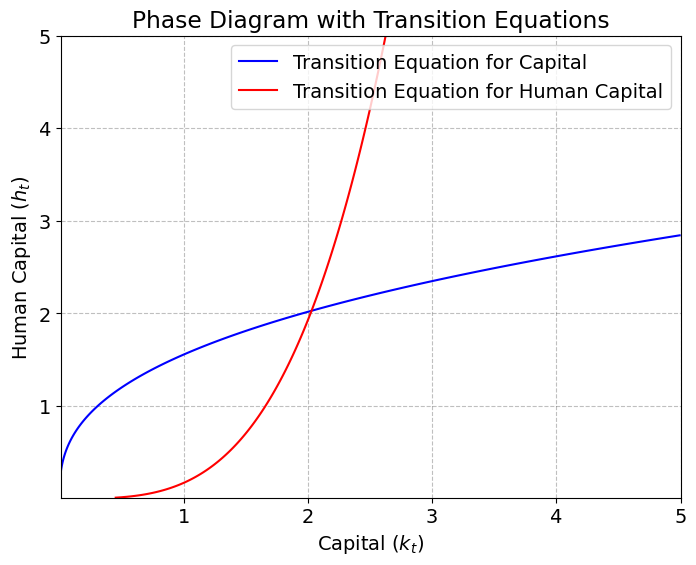

In [13]:
model.run()
model.plot_phase_diagram_transition_equations()

## Conclusion
The classic Solow Growth Model performs well under simulation and converges towards a steady state of capital. Under further analysis we show that our model coorporates with the wellknown  dynamics of the theoretical model. 

The extension of the model also shows convergence for both capital and human capital. The steady state value for capital is lower when including human capital, which does not comply with theory. This suggests an error in our extension.